# Cortical retinotopy vs. readout geometry (with vs. without retinotopy)

Same analysis as `cortex_retinotopy_vs_readout_distance.ipynb`, extended with the "no
retinotopy" ablation of each readout type, for 4 groups total:

- **Gaussian**: `grid_mean_predictor` of type `'cortex'` -- the readout's mean grid location is
  predicted from real cortical position via a learned network.
- **Gaussian, no retinotopy**: no `grid_mean_predictor` -- the mean grid location is a freely
  learned per-neuron parameter with no dependence on cortical position.
- **Factorized**: `retinotopy=True` -- the spatial mask logits are a learned linear function of
  real cortical position (`source_grid`).
- **Factorized, no retinotopy**: `retinotopy=False` -- the spatial mask (`raw_spatial`) is a
  freely learned per-neuron parameter with no dependence on cortical position.

For each of the 4 groups (3 seeds each), we whiten the per-neuron readout weight vectors (using
the pre-readout feature covariance, as in `try_analyze_whitening.ipynb`), then ask: do neurons
that sit close together in the readout's (feature) space also sit close together in the cortex?

For each recording session (animal) we compute the pairwise distance between neurons'
real cortical `(x, y)` position (`dataset.neurons.cell_motor_coordinates`) and the pairwise
distance between their (whitened) readout weight vectors, and take the Spearman correlation
between the two distance vectors. This is done per session (comparing distances *across*
animals would mix unrelated coordinate frames), then averaged over the 7 sessions to get one
number per seed, and finally averaged over seeds (mean +/- std) for the error bars.

Note: the "no retinotopy" factorized configs have `retinotopy: false` in `model_config.json`.
Unlike the original notebook (where dropping the key made no difference since the
with-retinotopy config value already matched the function default), here `retinotopy` must be
passed through as-is rather than dropped, otherwise the model would be (re)built with the wrong
readout architecture (`spatial_w`/`spatial_b` vs. `raw_spatial`) and fail to load the
checkpoint.

In [1]:
print('mew')

mew


In [2]:
import os
import json

import numpy as np
import torch
from tqdm import tqdm
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

from sensorium.utility import get_data, set_random_seed
from sensorium.models import stacked_core_full_gauss_readout, stacked_core_factorized_readout

random_seed = 42
set_random_seed(random_seed, deterministic=False)

device = 'cuda:6'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"
# as filenames, we'll select all 7 datasets

filenames = []
for file in [
    'static23343-5-17-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
    'static23964-4-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
    'static23656-14-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
    'static21067-10-18-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
    'static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
    'static22846-10-16-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
    'static27204-5-13-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
]:
    filenames.append(os.path.join(basepath, file))

dataset_fn = "sensorium.datasets.static_loaders"

dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "exclude_eye_position_paths": [
        '/srv/user/polina/sensorium/sensorium/notebooks/data/static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6'
    ],
    "batch_size": 128,
    "scale": 0.25,
}
dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

In [3]:
def load_model_from_config(run_dir, dataloaders, device='cuda:0', strict=True):
    """Handles both the Gaussian and Factorized readout configs used across the four run trees.

    `retinotopy` is passed through as-is (not popped) since it is a real kwarg of
    `stacked_core_factorized_readout` and its value differs between the with/without-retinotopy
    factorized runs.
    """
    with open(f'{run_dir}/model_config.json', 'r') as f:
        full_config = json.load(f)

    readout_type = full_config['readout_type']
    model_config = full_config['model_config']
    seed = full_config['random_seed']

    if readout_type == 'gaussian':
        model = stacked_core_full_gauss_readout(dataloaders, seed, **model_config)
    elif readout_type == 'factorized':
        model = stacked_core_factorized_readout(dataloaders, seed, **model_config)
    else:
        raise ValueError(f"Unknown readout_type: {readout_type}")

    state_dict = torch.load(f'{run_dir}/model_weights.pth', map_location=device)
    model.load_state_dict(state_dict, strict=strict)
    model.to(device)
    model.eval()

    return model, readout_type


def load_models(pre_path, runs, expected_readout_type):
    models = []
    for run in runs:
        model, readout_type = load_model_from_config(f'{pre_path}{run}', dataloaders, device, strict=True)
        assert readout_type == expected_readout_type, (run, readout_type)
        models.append(model)
    return models


models_by_type = {
    'gaussian': load_models(
        '/user/nathanpaul.soeding/sensorium/training/runs/baseline/',
        ['baseline_seed9', 'baseline_seed87', 'baseline_seed333'],
        'gaussian',
    ),
    'gaussian_no_retinotopy': load_models(
        '/user/nathanpaul.soeding/sensorium/training/runs/baseline/no_retinotopy/',
        ['baseline_no_retinotopy_seed0', 'baseline_no_retinotopy_seed42', 'baseline_no_retinotopy_seed123'],
        'gaussian',
    ),
    'factorized': load_models(
        '/user/nathanpaul.soeding/sensorium/training/runs/whiten_reg/nonwhiten/reg3/',
        ['nonwhite_reg3_seed42', 'nonwhite_reg3_seed123', 'nonwhite_reg3_seed0'],
        'factorized',
    ),
    'factorized_no_retinotopy': load_models(
        '/user/nathanpaul.soeding/sensorium/training/runs/no_retinotopy/',
        ['no_retinotopy_seed0', 'no_retinotopy_seed42', 'no_retinotopy_seed123'],
        'factorized',
    ),
}

# which readout family each group belongs to (controls feature-matrix orientation when whitening)
readout_family = {
    'gaussian': 'gaussian',
    'gaussian_no_retinotopy': 'gaussian',
    'factorized': 'factorized',
    'factorized_no_retinotopy': 'factorized',
}

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/turishcheva/nathans_code/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_sca

## Whiten the readout weights (per session)

In [4]:
def get_stats(X):
    mu = X.mean(0, keepdim=True)
    Xc = X - mu
    cov = Xc.T @ Xc / (X.shape[0] - 1)
    return mu, cov


def get_train_features(model, dataloaders, data_keys, device):
    """Push the training split through the model and collect the pre-readout feature vector for every image."""
    mode_features = []
    for key in data_keys:
        batch_features = []
        for batch in tqdm(dataloaders['train'][key], leave=False):
            img, target, behav = batch[:3]
            img = img.to(device)

            if len(batch) == 4:
                pupil = batch[3].to(device)
            else:
                pupil = None

            pred, feature = model(img, data_key=key, pupil_center=pupil, return_vec=True)
            batch_features.append(feature.detach().cpu())
        mode_features.append(torch.cat(batch_features))

    return torch.cat([f.flatten(0, 1) for f in mode_features])


def whiten_readouts(cov, readouts, eps=1e-5):
    eye = torch.eye(cov.shape[0], dtype=cov.dtype)
    L = torch.linalg.cholesky(cov + eps * eye)
    whitened_readouts = L.T @ readouts.T
    return whitened_readouts.T


def get_session_readouts(model, data_keys, readout_type):
    """Per-session (num_neurons, feature_dim) readout weight matrices, in dataset-neuron order."""
    out = {}
    for key in data_keys:
        feat = model.readout[key].features.detach().squeeze().cpu()
        if readout_type == 'gaussian':
            feat = feat.T  # gaussian readout stores features as (feature_dim, num_neurons)
        out[key] = feat
    return out


def whiten_model(model, dataloaders, data_keys, device, readout_type):
    """Returns a dict data_key -> whitened (num_neurons, feature_dim) readout matrix (numpy)."""
    model.eval()
    with torch.no_grad():
        train_features = get_train_features(model, dataloaders, data_keys, device)
        _, train_cov = get_stats(train_features)

    session_readouts = get_session_readouts(model, data_keys, readout_type)
    session_whitened = {key: whiten_readouts(train_cov, r).numpy() for key, r in session_readouts.items()}

    del train_features
    torch.cuda.empty_cache()
    return session_whitened


whitened_by_type = {
    group: [
        whiten_model(model, dataloaders, data_keys, device, readout_family[group])
        for model in tqdm(models, desc=f'whitening {group} models')
    ]
    for group, models in models_by_type.items()
}

whitening factorized_no_retinotopy models: 100%|██████████| 3/3 [07:17<00:00, 145.74s/it]


## Real cortical (x, y) positions and their pairwise distances

In [5]:
cortex_coords = {
    key: dataloaders['train'][key].dataset.neurons.cell_motor_coordinates[:, :2].astype(float)
    for key in data_keys
}
cortex_dists = {key: pdist(coords) for key, coords in cortex_coords.items()}

{key: coords.shape for key, coords in cortex_coords.items()}

{'23343-5-17': (7334, 2),
 '23964-4-22': (8098, 2),
 '23656-14-22': (8107, 2),
 '21067-10-18': (8372, 2),
 '26872-17-20': (7776, 2),
 '22846-10-16': (7344, 2),
 '27204-5-13': (7538, 2)}

## Spearman correlation: cortical distance vs. readout distance (whitened)

For every seed, average the per-session Spearman rho over the 7 sessions; error bars are
mean +/- std across the 3 seeds.

In [6]:
def session_rhos(session_embeddings, cortex_dists, data_keys):
    """Per-session Spearman rho between cortical distance and embedding distance."""
    rhos = []
    for key in data_keys:
        emb_dist = pdist(session_embeddings[key])
        rho, _ = spearmanr(cortex_dists[key], emb_dist)
        rhos.append(rho)
    return np.array(rhos)


def seed_mean_rhos(list_of_session_dicts, cortex_dists, data_keys):
    """One (session-averaged) rho per seed, plus the raw (seed, session) rho matrix."""
    per_session = np.stack([
        session_rhos(session_dict, cortex_dists, data_keys)
        for session_dict in list_of_session_dicts
    ])  # (n_seeds, n_sessions)
    return per_session.mean(axis=1), per_session


groups = list(models_by_type)
labels = {
    'gaussian': 'Gaussian',
    'gaussian_no_retinotopy': 'Gaussian, no retinotopy',
    'factorized': 'Factorized',
    'factorized_no_retinotopy': 'Factorized, no retinotopy',
}
colors = {
    'gaussian': 'steelblue',
    'gaussian_no_retinotopy': 'skyblue',
    'factorized': 'peru',
    'factorized_no_retinotopy': 'sandybrown',
}

rho_per_seed = {}
rho_per_session = {}
for group in groups:
    rho_per_seed[group], rho_per_session[group] = seed_mean_rhos(whitened_by_type[group], cortex_dists, data_keys)
    print(f'{group:26s}', rho_per_seed[group].mean(), '+/-', rho_per_seed[group].std(ddof=1))

gaussian                   0.04233535329943317 +/- 0.005819809861462612
gaussian_no_retinotopy     0.02869360604375784 +/- 0.0018627020067659042
factorized                 0.015136200097238229 +/- 0.0018354121627662972
factorized_no_retinotopy   0.06343612255323328 +/- 0.001962850730794132


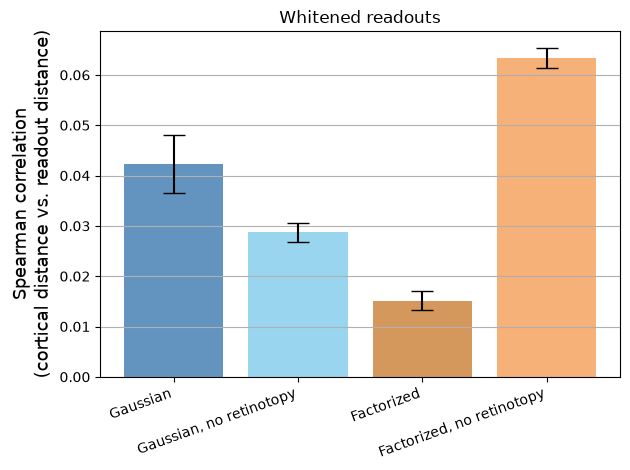

In [7]:
means = [rho_per_seed[g].mean() for g in groups]
stds = [rho_per_seed[g].std(ddof=1) for g in groups]

plt.bar([labels[g] for g in groups], means, yerr=stds, capsize=8, color=[colors[g] for g in groups], alpha=0.85)
plt.ylabel('Spearman correlation\n(cortical distance vs. readout distance)', fontsize=13)
plt.title('Whitened readouts')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y')
plt.tight_layout()

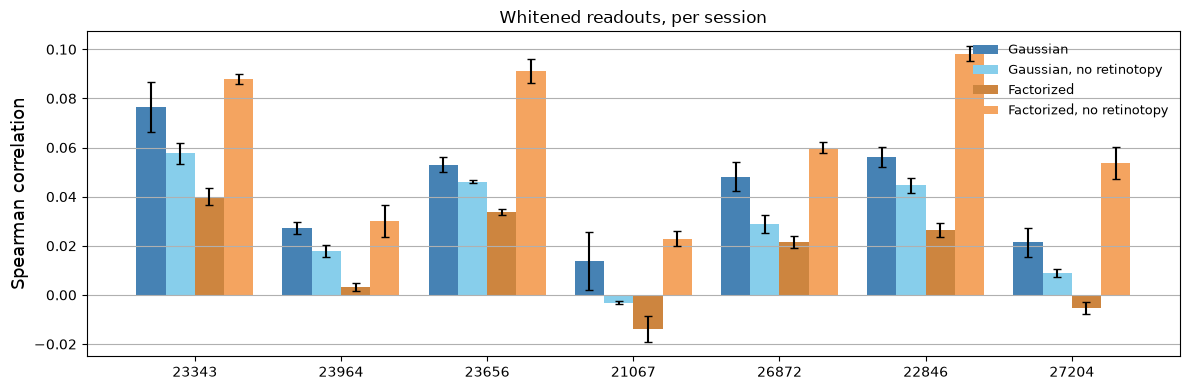

In [8]:
x = np.arange(len(data_keys))
n_groups = len(groups)
width = 0.8 / n_groups
offsets = (np.arange(n_groups) - (n_groups - 1) / 2) * width

fig, ax = plt.subplots(figsize=(12, 4))
for offset, group in zip(offsets, groups):
    ax.bar(x + offset, rho_per_session[group].mean(axis=0), width,
           yerr=rho_per_session[group].std(axis=0, ddof=1), capsize=3,
           label=labels[group], color=colors[group])

ax.set_xticks(x)
ax.set_xticklabels([key.split('-')[0] for key in data_keys], rotation=0)
ax.set_ylabel('Spearman correlation', fontsize=13)
ax.set_title('Whitened readouts, per session')
ax.grid(axis='y')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()

## New section: normalized + whitened embeddings

Same analysis, but each neuron's whitened readout vector is L2-normalized before computing
readout-space distances (removes any contribution of overall vector magnitude, leaving only
direction).

In [9]:
def normalize_session_dict(session_dict):
    return {key: r / np.linalg.norm(r, axis=1, keepdims=True) for key, r in session_dict.items()}


whitened_normed_by_type = {group: [normalize_session_dict(d) for d in dicts] for group, dicts in whitened_by_type.items()}

rho_per_seed_normed = {}
rho_per_session_normed = {}
for group in groups:
    rho_per_seed_normed[group], rho_per_session_normed[group] = seed_mean_rhos(
        whitened_normed_by_type[group], cortex_dists, data_keys
    )
    print(f'{group:26s}', rho_per_seed_normed[group].mean(), '+/-', rho_per_seed_normed[group].std(ddof=1))

gaussian                   0.17398135105771484 +/- 0.007981060648450692
gaussian_no_retinotopy     0.14611627548729647 +/- 0.0004342299454336044
factorized                 0.1809709572183973 +/- 0.0021353511969599104
factorized_no_retinotopy   0.1613842757517052 +/- 0.006334653250024314


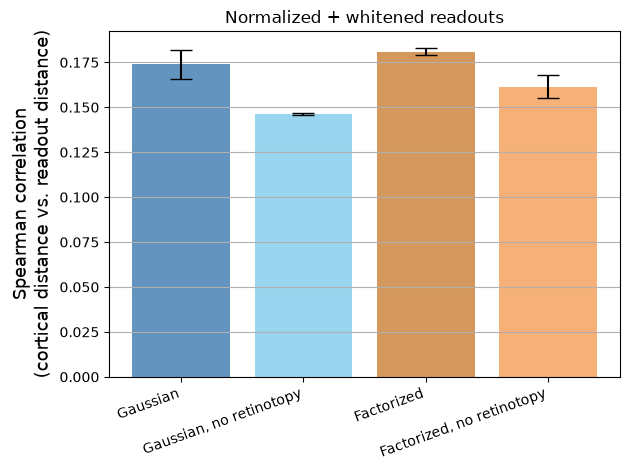

In [10]:
means_normed = [rho_per_seed_normed[g].mean() for g in groups]
stds_normed = [rho_per_seed_normed[g].std(ddof=1) for g in groups]

plt.bar([labels[g] for g in groups], means_normed, yerr=stds_normed, capsize=8, color=[colors[g] for g in groups], alpha=0.85)
plt.ylabel('Spearman correlation\n(cortical distance vs. readout distance)', fontsize=13)
plt.title('Normalized + whitened readouts')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y')
plt.tight_layout()

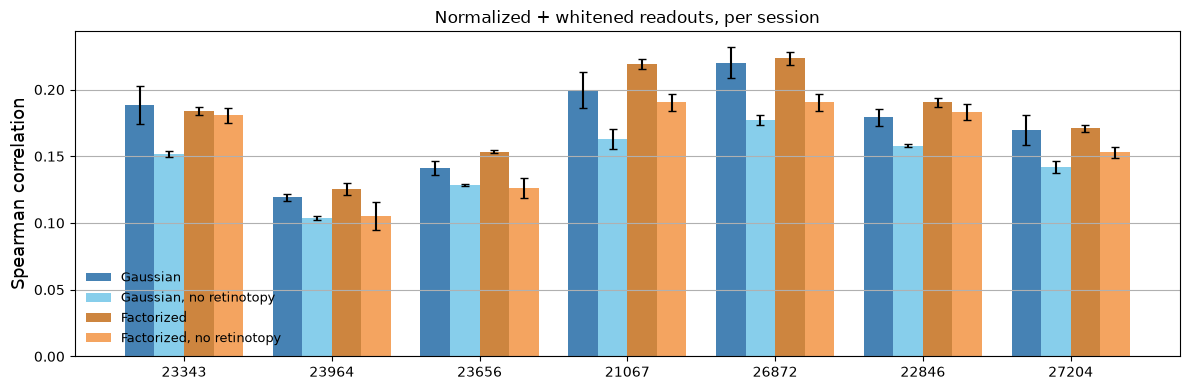

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
for offset, group in zip(offsets, groups):
    ax.bar(x + offset, rho_per_session_normed[group].mean(axis=0), width,
           yerr=rho_per_session_normed[group].std(axis=0, ddof=1), capsize=3,
           label=labels[group], color=colors[group])

ax.set_xticks(x)
ax.set_xticklabels([key.split('-')[0] for key in data_keys], rotation=0)
ax.set_ylabel('Spearman correlation', fontsize=13)
ax.set_title('Normalized + whitened readouts, per session')
ax.grid(axis='y')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()

In [13]:
import pickle

In [14]:
# with open('/srv/user/turishcheva/nathans_code/sensorium/analysis/cortex_vs_embeddings_with_no_retinotopy.pkl', 'wb') as f:
#     pickle.dump(rho_per_session_normed, f)

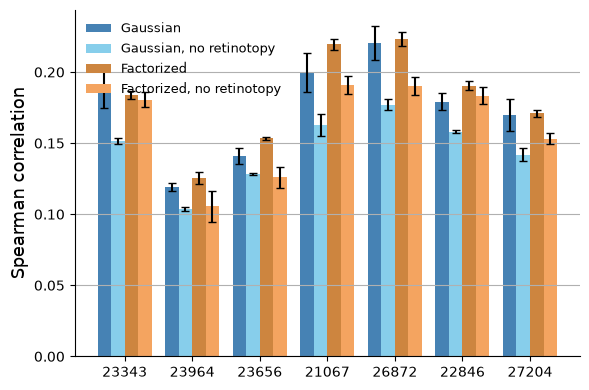

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
for offset, group in zip(offsets, groups):
    ax.bar(x + offset, rho_per_session_normed[group].mean(axis=0), width,
           yerr=rho_per_session_normed[group].std(axis=0, ddof=1), capsize=3,
           label=labels[group], color=colors[group])

ax.set_xticks(x)
ax.set_xticklabels([key.split('-')[0] for key in data_keys], rotation=0)
ax.set_ylabel('Spearman correlation', fontsize=13)
# ax.set_title('Normalized + whitened readouts, per session')
ax.grid(axis='y')
ax.legend(frameon=False, fontsize=9)
ax.spines[['right', 'top']].set_visible(False)
plt.tight_layout()

In [18]:
with open('/srv/user/turishcheva/nathans_code/sensorium/analysis/cortex_vs_com_with_no_retinotopy.pkl', 'rb') as f:
    rho_per_session_v2 = pickle.load(f)

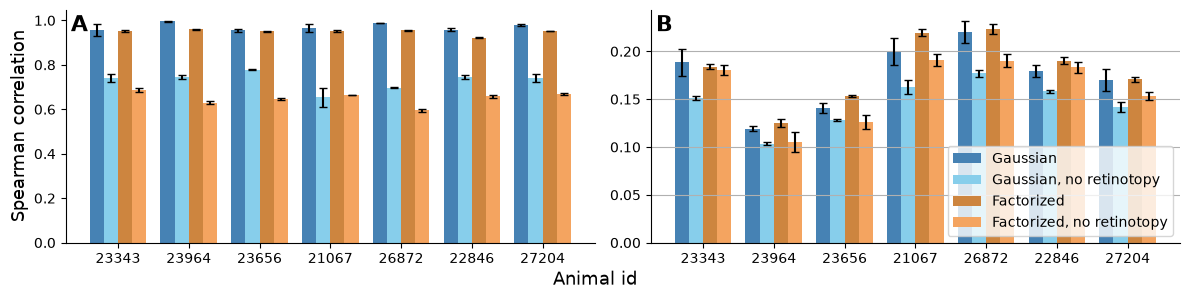

In [61]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
for offset, group in zip(offsets, groups):
    ax[1].bar(x + offset, rho_per_session_normed[group].mean(axis=0), width,
           yerr=rho_per_session_normed[group].std(axis=0, ddof=1), capsize=3,
           label=labels[group], color=colors[group])

for offset, group in zip(offsets, groups):
    ax[0].bar(x + offset, rho_per_session_v2[group].mean(axis=0), width,
           yerr=rho_per_session_v2[group].std(axis=0, ddof=1), capsize=3,
           label=labels[group], color=colors[group])

ax[1].set_xticks(x)
ax[1].set_xticklabels([key.split('-')[0] for key in data_keys], rotation=0)
ax[0].set_ylabel('Spearman correlation', fontsize=13)
# ax.set_title('Normalized + whitened readouts, per session')
ax[1].grid(axis='y')
ax[1].legend(frameon=True, fontsize=10, ncols=1, loc="lower right",
    facecolor=(1, 1, 1, 1),  
)
    # edgecolor="none",  )# Optional: removes the border outline)
ax[1].spines[['right', 'top']].set_visible(False)
ax[0].spines[['right', 'top']].set_visible(False)
ax[0].set_xticks(x)
ax[0].set_xticklabels([key.split('-')[0] for key in data_keys], rotation=0)
fig.supxlabel("Animal id", y=0.08, fontsize=13)
for label, a in zip(["A", "B"], ax):
  a.text(
      0.01,
      0.98,
      label,
      transform=a.transAxes,
      fontsize=16,
      fontweight="bold",
      va="top",
  )
plt.tight_layout()
plt.savefig(
    'coordinates_correlations_v2.pdf',
    transparent=True,
    bbox_inches='tight',
    pad_inches=0,
)
